Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Dataset path: /kaggle/input/fake-and-real-news-dataset
                                                    text  label
22216  21st Century Wire says Ben Stein, reputable pr...      0
4436   WASHINGTON (Reuters) - U.S. President Donald T...      1
1526   (Reuters) - Puerto Rico Governor Ricardo Rosse...      1
1377   On Monday, Donald Trump once again embarrassed...      0
8995   GLASGOW, Scotland (Reuters) - Most U.S. presid...      1
Train size: 8000
Test size: 2000
Vocabulary size: 5000
Using device: cpu
Epoch 1 Loss: 0.6535
Epoch 2 Loss: 0.4672
Epoch 3 Loss: 0.4017


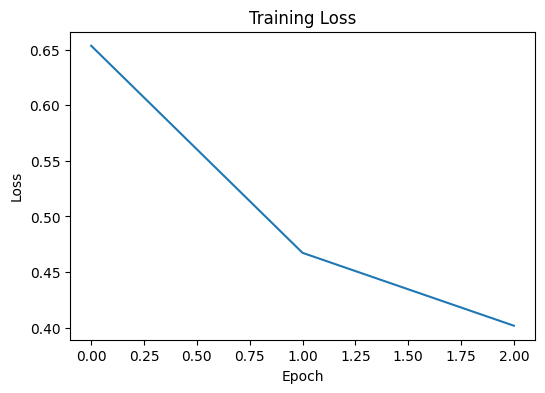

Test Accuracy: 0.8165

Classification Report:

              precision    recall  f1-score   support

         0.0       0.97      0.68      0.80      1081
         1.0       0.72      0.97      0.83       919

    accuracy                           0.82      2000
   macro avg       0.85      0.83      0.82      2000
weighted avg       0.86      0.82      0.81      2000



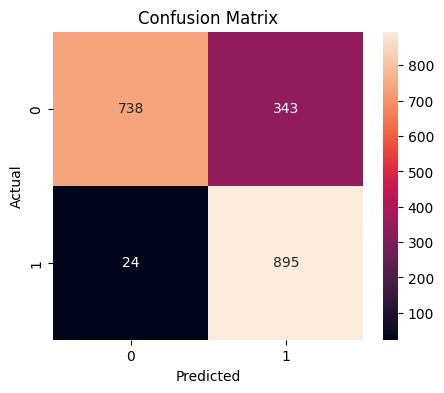

Results saved!
Model saved!


In [8]:
# INSTALL
!pip install kagglehub -q

import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from torch.utils.data import Dataset, DataLoader

# DOWNLOAD DATASET AUTOMATICALLY

import kagglehub

path = kagglehub.dataset_download(
    "clmentbisaillon/fake-and-real-news-dataset"
)

print("Dataset path:", path)


# LOAD DATA

fake_df = pd.read_csv(path + "/Fake.csv")

true_df = pd.read_csv(path + "/True.csv")

# Labels
fake_df["label"] = 0
true_df["label"] = 1

# Merge
df = pd.concat([fake_df, true_df])

# Use only needed columns
df = df[["text", "label"]]

# Small subset for faster training
df = df.sample(10000, random_state=42)

print(df.head())

# CLEAN TEXT

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df["text"] = df["text"].apply(clean_text)


# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    df["text"].values,
    df["label"].values,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

# VOCABULARY


MAX_VOCAB = 5000
MAX_LEN = 100

counter = Counter()

for text in X_train:
    counter.update(text.split())

most_common = counter.most_common(MAX_VOCAB - 2)

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

print("Vocabulary size:", len(word2idx))

# ENCODING FUNCTION

def encode(text):

    tokens = []

    for word in text.split():

        tokens.append(word2idx.get(word, 1))

    tokens = tokens[:MAX_LEN]

    while len(tokens) < MAX_LEN:
        tokens.append(0)

    return tokens

# DATASET CLASS

class NewsDataset(Dataset):

    def __init__(self, texts, labels):

        self.X = torch.tensor(
            [encode(text) for text in texts],
            dtype=torch.long
        )

        self.y = torch.tensor(
            labels,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.y)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

# DATALOADERS

train_dataset = NewsDataset(
    X_train,
    y_train
)

test_dataset = NewsDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

# LSTM MODEL

class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            len(word2idx),
            128
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(
            128,
            1
        )

    def forward(self, x):

        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        output = self.fc(hidden[-1])

        return output.squeeze(1)

# DEVICE

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# MODEL SETUP


model = LSTMModel().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# TRAINING LOOP


loss_history = []

EPOCHS = 3

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1} Loss: {avg_loss:.4f}"
    )


# LOSS GRAPH

plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

# EVALUATION

model.eval()

predictions = []

real_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        preds = torch.sigmoid(outputs)

        preds = (preds > 0.5).int()

        predictions.extend(
            preds.cpu().numpy()
        )

        real_labels.extend(
            labels.numpy()
        )


# ACCURACY

accuracy = accuracy_score(
    real_labels,
    predictions
)

print("Test Accuracy:", accuracy)

# CLASSIFICATION REPORT

print("\nClassification Report:\n")

print(
    classification_report(
        real_labels,
        predictions
    )
)


# CONFUSION MATRIX

cm = confusion_matrix(
    real_labels,
    predictions
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# SAVE RESULTS

results = pd.DataFrame({
    "accuracy": [accuracy]
})

results.to_csv(
    "lstm_results.csv",
    index=False
)

print("Results saved!")


# SAVE MODEL

torch.save(
    model.state_dict(),
    "lstm_model.pth"
)

print("Model saved!")